In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import sqlite3
import os
from tqdm.notebook import tqdm

# Define file paths
json_file_path = '/content/drive/Shareddrives/Hotels/Full_HotelRec/HotelRec.txt'

# Ensure the directory exists
drive_dir = os.path.dirname(json_file_path)

# Define the SQLite database file path
sqlite_db_path = os.path.join(drive_dir, 'HotelRec.db')

# Function to flatten property_dict keys
def flatten_property_dict(property_dict):
    flattened_dict = {}
    for key, value in property_dict.items():
        new_key = key.replace(' ', '_')
        flattened_dict[new_key] = value
    return flattened_dict

try:
    # Connect to SQLite database
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # Create table schema
    create_table_sql = """
    CREATE TABLE IF NOT EXISTS hotel_reviews (
        hotel_url TEXT,
        author TEXT,
        date TEXT,
        rating REAL,
        title TEXT,
        text TEXT,
        sleep_quality REAL,
        value REAL,
        rooms REAL,
        service REAL,
        cleanliness REAL,
        location REAL
    );
    """
    cursor.execute(create_table_sql)
    conn.commit()
    print("Table 'hotel_reviews' checked/created successfully.")

    file_size = os.path.getsize(json_file_path)

    # Open and process the JSON file with tqdm tracking bytes
    with open(json_file_path, 'r') as f:
        with tqdm(total=file_size, unit='B', unit_scale=True, desc="Loading data") as pbar:
            for line_num, line in enumerate(f, 1):
                try:
                    data = json.loads(line.strip())

                    # Flatten the property_dict
                    property_data = flatten_property_dict(data.get('property_dict', {}))

                    # Prepare data for insertion
                    insert_data = (
                        data.get('hotel_url'),
                        data.get('author'),
                        data.get('date'),
                        data.get('rating'),
                        data.get('title'),
                        data.get('text'),
                        property_data.get('sleep_quality'),
                        property_data.get('value'),
                        property_data.get('rooms'),
                        property_data.get('service'),
                        property_data.get('cleanliness'),
                        property_data.get('location')
                    )

                    # Insert data into the table
                    insert_sql = """
                    INSERT INTO hotel_reviews (
                        hotel_url, author, date, rating, title, text,
                        sleep_quality, value, rooms, service, cleanliness, location
                    )
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?);
                    """
                    cursor.execute(insert_sql, insert_data)

                    # Update tqdm progress by the byte length of the line
                    pbar.update(len(line.encode('utf-8')))

                except json.JSONDecodeError as e:
                    print(f"Skipping line {line_num} due to error: {e}")
                except Exception as e:
                    print(f"An error occurred while processing line {line_num}: {e}")

    # Commit all changes and close the connection
    conn.commit()
    print(f"Successfully loaded data into SQLite database: {sqlite_db_path}")

except FileNotFoundError:
    print(f"Error: JSON file not found at {json_file_path}.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
finally:
    if 'conn' in locals() and conn:
        conn.close()
        print("Database connection closed.")

Table 'hotel_reviews' checked/created successfully.


Loading data:   0%|          | 0.00/50.4G [00:00<?, ?B/s]

Successfully loaded data into SQLite database: /content/drive/Shareddrives/Hotels/Full_HotelRec/HotelRec.db
Database connection closed.


In [ ]:
#count number of entries in HotelRec.db database
import sqlite3


In [ ]:
import sqlite3

conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # Select the first 10 entries
    cursor.execute("SELECT * FROM hotel_reviews LIMIT 10;")
    rows = cursor.fetchall()

    # Print the column names
    column_names = [description[0] for description in cursor.description]
    print(column_names)

    # Print the rows
    for row in rows:
        print(row)

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")

['hotel_url', 'author', 'date', 'rating', 'title', 'text', 'sleep_quality', 'value', 'rooms', 'service', 'cleanliness', 'location']
('Hotel_Review-g194775-d1121769-Reviews-Hotel_Baltic-Giulianova_Province_of_Teramo_Abruzzo.html', 'violettaf340', '2019-01-01T00:00:00', 5.0, 'Xmas holiday', 'We went here with our kids for Xmas holiday and we really liked it. Large options of food for breakfast and lunch , you can really taste the quality of the food in there. The surrounding area is nice and clean. Good experience. Hardly recommended .', None, None, None, None, None, None)
('Hotel_Review-g194775-d1121769-Reviews-Hotel_Baltic-Giulianova_Province_of_Teramo_Abruzzo.html', 'Lagaiuzza', '2016-01-01T00:00:00', 5.0, 'Baltic, what else?', 'We have spent in this hotel our summer holidays both in summer 2014 and 2015- I was with my husband and my child ( 4 years old at present). I do really recommend this place- Staff si high qualified, Kind and really helpful- Animation staff get You involved, bu

In [ ]:
import sqlite3

conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # Count the number of entries
    cursor.execute("SELECT COUNT(*) FROM hotel_reviews;")
    count = cursor.fetchone()[0]

    print(f"Total number of entries in 'hotel_reviews' table: {count}")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")

Total number of entries in 'hotel_reviews' table: 50264531
Database connection closed.


In [ ]:
import sqlite3

conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # Count the number of unique authors
    cursor.execute("SELECT COUNT(DISTINCT author) FROM hotel_reviews;")
    unique_authors_count = cursor.fetchone()[0]

    print(f"Total number of unique authors in 'hotel_reviews' table: {unique_authors_count}")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")

Total number of unique authors in 'hotel_reviews' table: 21891404
Database connection closed.


In [ ]:
conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # Count the number of unique authors
    cursor.execute("SELECT COUNT(DISTINCT hotel_url) FROM hotel_reviews;")
    unique_hotelurl_count = cursor.fetchone()[0]

    print(f"Total number of unique hotel urls in 'hotel_reviews' table: {unique_hotelurl_count}")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")

Total number of unique hotel urls in 'hotel_reviews' table: 365057
Database connection closed.


In [ ]:
import sqlite3

conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # Count the number of unique hotel_url and author pairs using GROUP BY
    cursor.execute("SELECT COUNT(*) FROM (SELECT hotel_url, author FROM hotel_reviews GROUP BY hotel_url, author);")
    unique_pairs_count = cursor.fetchone()[0]

    print(f"Total number of unique hotel_url and author pairs in 'hotel_reviews' table: {unique_pairs_count}")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")

Total number of unique hotel_url and author pairs in 'hotel_reviews' table: 47793516
Database connection closed.


In [ ]:
#check for duplicates in database
import sqlite3


In [2]:
sqlite_db_path = '/content/drive/Shareddrives/Hotels/Full_HotelRec/HotelRec.db'

In [5]:
import sqlite3

conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # Count the number of unique hotel_url and author pairs using GROUP BY
    cursor.execute("SELECT COUNT(*) FROM (SELECT author, date FROM hotel_reviews GROUP BY author, date);")
    unique_pairs_count = cursor.fetchone()[0]

    print(f"Total number of unique  author, date pairs in 'hotel_reviews' table: {unique_pairs_count}")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")

Total number of unique  author, date pairs in 'hotel_reviews' table: 40816256
Database connection closed.


In [9]:
import sqlite3

conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)
    cursor = conn.cursor()

    # SQL query to find duplicates based on hotel_url, author, date, rating, and text
    # and count the number of redundant rows
    query = """
    SELECT SUM(count_of_reviews - 1) AS num_duplicates
    FROM (
        SELECT
            hotel_url,
            author,
            date,
            rating,
            text,
            COUNT(*) AS count_of_reviews
        FROM
            hotel_reviews
        GROUP BY
            hotel_url,
            author,
            date,
            rating,
            text
        HAVING
            COUNT(*) > 1
    );
    """

    cursor.execute(query)
    num_duplicates = cursor.fetchone()[0]

    if num_duplicates is None: # Handle case where no duplicates are found
        num_duplicates = 0

    print(f"Number of duplicate entries based on (hotel_url, author, date, rating, text): {num_duplicates}")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")

Number of duplicate entries based on (hotel_url, author, date, rating, text): 167
Database connection closed.


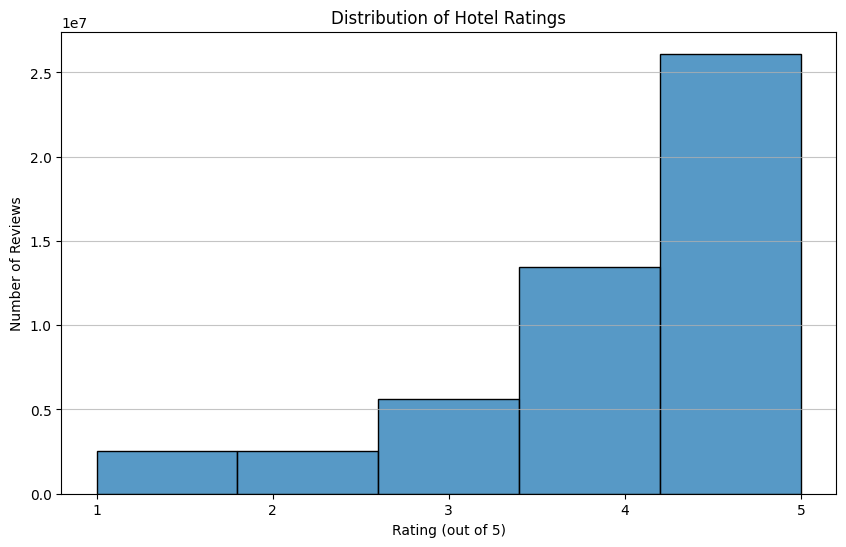

Database connection closed.


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = None # Initialize conn outside try block
try:
    conn = sqlite3.connect(sqlite_db_path)

    # Fetch all ratings from the hotel_reviews table
    ratings_df = pd.read_sql_query("SELECT rating FROM hotel_reviews WHERE rating IS NOT NULL;", conn)

    # Create a histogram of the ratings distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(ratings_df['rating'], bins=5, kde=False, stat='count')
    plt.title('Distribution of Hotel Ratings')
    plt.xlabel('Rating (out of 5)')
    plt.ylabel('Number of Reviews')
    plt.xticks(ticks=[1, 2, 3, 4, 5])
    plt.grid(axis='y', alpha=0.75)
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if conn:
        conn.close()
        print("Database connection closed.")